# 01 · RNN Fundamentals — Intuition, Memory & the Flow of Information

Welcome! This is the **first** notebook of a series that teaches Recurrent Neural Networks (RNNs)
from the ground up. By the end of the series you will be comfortable building GRUs and LSTMs to
solve real consulting-style problems (classification, generation, and high-frequency sensor
forecasting for the energy industry).

In this notebook we deliberately write **no training code at all**. The goal here is pure
*understanding*:

1. What "sequential data" is and why ordinary (feed-forward) networks struggle with it.
2. The **one idea** behind every RNN: a *hidden state* that acts as **memory**.
3. The **recurrence equation** and how information *flows through time* (the "unrolling").
4. The **five classic RNN shapes**: one-to-one, one-to-many, many-to-one, many-to-many
   (aligned) and many-to-many (encoder–decoder / seq2seq).
5. A **from-scratch RNN cell in pure NumPy** so you can see every number moving.

> 📚 **How to read this series** — each notebook is standalone but they build on each other:
> `01 fundamentals → 02 first PyTorch RNN → 03 LSTM & GRU → 04 classification →
> 05 generation → 06 energy/sensor forecasting`.

## 1. Sequential data: order carries meaning

Most "classic" machine-learning problems assume each row of data is **independent**: predicting
a house price from its size, or whether a passenger survived the Titanic. Shuffling the rows
changes nothing.

**Sequential data is different — the *order* is part of the signal.** Examples:

| Domain | Sequence | Why order matters |
|---|---|---|
| Language | "the movie was **not** good" | move `not` and the meaning flips |
| Finance | daily prices | tomorrow depends on the recent trend |
| Energy | power meter every second | load now depends on load a moment ago |
| Health | ECG / heartbeat | the *shape over time* is the diagnosis |
| Industry | vibration sensor on a turbine | a rising trend signals a failure |

A plain feed-forward network (an MLP) has two problems with sequences:

- **Fixed input size** — an MLP needs exactly *N* inputs, but sentences and sensor streams have
  *variable* length.
- **No memory** — it treats position 5 exactly like position 500; it cannot "remember" what came
  before.

RNNs fix both. Let's see the core idea.

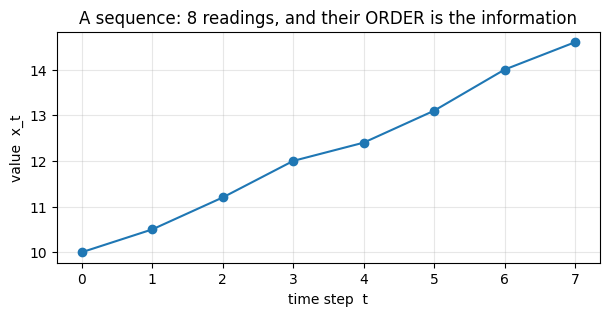

At each time step the network will see ONE element: [10.0, 10.5, 11.2, 12.0, 12.4, 13.1, 14.0, 14.6]


In [1]:
# We only need numpy and matplotlib for this whole notebook. No deep-learning framework yet —
# the point is to see the mechanics with our own eyes.
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(0)  # reproducibility: same "random" numbers every run

# A tiny toy sequence: a temperature reading that drifts up over 8 time steps.
sequence = np.array([10.0, 10.5, 11.2, 12.0, 12.4, 13.1, 14.0, 14.6])

plt.figure(figsize=(7, 3))
plt.plot(sequence, marker="o")
plt.title("A sequence: 8 readings, and their ORDER is the information")
plt.xlabel("time step  t")
plt.ylabel("value  x_t")
plt.grid(alpha=0.3)
plt.show()

print("At each time step the network will see ONE element:", sequence.tolist())

## 2. The one big idea: a hidden state that remembers

An RNN reads a sequence **one element at a time**. After reading each element it updates a small
vector called the **hidden state** `h` — think of it as the network's *memory* or *running
summary* of everything it has seen so far.

At every time step `t` the RNN does the **same** small computation:

- takes the **current input** `x_t`
- takes the **previous memory** `h_{t-1}`
- mixes them together to produce the **new memory** `h_t`
- (optionally) produces an **output** `y_t`

Because the memory `h_t` is fed back in at the next step, information can *persist* and *flow
forward through time*. That feedback loop is literally what "recurrent" means.

```
          ┌─────────────┐
   x_t ──▶│   RNN cell  │──▶ h_t  ──▶ (output y_t)
          │             │
   h_{t-1}▶│  (memory)   │
          └─────────────┘
                 ▲  │
                 └──┘  the new memory becomes the next step's "previous memory"
```

### The recurrence equation

A **vanilla RNN** cell computes the new hidden state with one line of math:

$$ h_t = \tanh\!\big(W_{xh}\, x_t \;+\; W_{hh}\, h_{t-1} \;+\; b_h\big) $$

and, when we want a prediction at that step:

$$ y_t = W_{hy}\, h_t + b_y $$

Reading the symbols:

| Symbol | Meaning | Shape (intuition) |
|---|---|---|
| $x_t$ | input at time *t* | a vector of *input features* |
| $h_{t-1}$ | memory from the previous step | a vector of *hidden units* |
| $h_t$ | updated memory | same size as $h_{t-1}$ |
| $W_{xh}$ | how the input influences memory | (hidden × input) |
| $W_{hh}$ | how old memory influences new memory | (hidden × hidden) |
| $W_{hy}$ | how memory maps to an output | (output × hidden) |
| $b_h, b_y$ | biases | — |
| $\tanh$ | squashing function keeping values in (−1, 1) | — |

**The crucial detail:** the weights $W_{xh}, W_{hh}, W_{hy}$ are **the same at every time step**.
The RNN applies one identical rule over and over. This *weight sharing* is what lets an RNN
handle sequences of **any length** with a fixed, small number of parameters.

**Important**: W_xx are learnable parameters, updated by gradient descente. So we initialize them with Xavier, Kaiming or similar methods. But hidden states are NOT learnable parameters. They are the "memory" of the network. We initialize the hidden state to zeros at the start of each sequence, but it is updated as we process each time step.

## 3. "Unrolling": how the flow through time really looks

Drawing the feedback loop is compact but hard to reason about. If we **unroll** the loop — draw
one copy of the same cell for each time step — the flow becomes obvious. Information moves
**left to right along the arrow of time**, carried by the hidden state.

```
 x_1        x_2        x_3        x_4
  │          │          │          │
  ▼          ▼          ▼          ▼
┌────┐ h_1 ┌────┐ h_2 ┌────┐ h_3 ┌────┐ h_4
│cell│────▶│cell│────▶│cell│────▶│cell│────▶ ...
└────┘     └────┘     └────┘     └────┘
  │          │          │          │
  ▼          ▼          ▼          ▼
 y_1        y_2        y_3        y_4     (outputs, if we want one per step)
```

Every box is **the same cell with the same weights**. The horizontal arrows carry the memory
`h`. This picture is why training an RNN is called **Back-Propagation Through Time (BPTT)** —
gradients flow *backwards* along those same horizontal arrows (we'll meet BPTT and its famous
"vanishing gradient" problem in notebook 03).

Let's draw this unrolled diagram with matplotlib so it sticks.

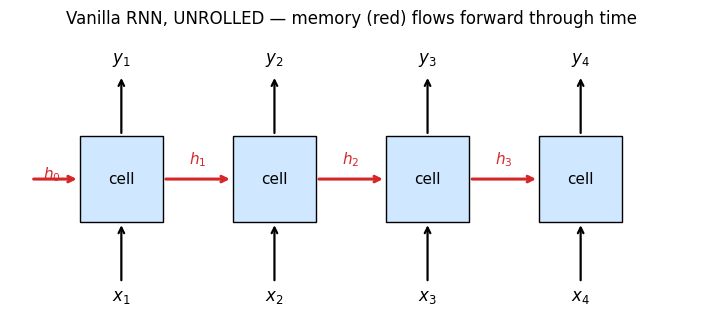

In [2]:
def draw_unrolled_rnn(n_steps=4):
    '''Draw an RNN unrolled across `n_steps` time steps to visualize the flow of information.'''
    fig, ax = plt.subplots(figsize=(2.2 * n_steps, 3.6))
    for t in range(n_steps):
        x = t * 2.2
        # the recurrent cell (a box)
        ax.add_patch(plt.Rectangle((x, 1), 1.2, 1, fill=True, color="#cfe8ff", ec="black"))
        ax.text(x + 0.6, 1.5, f"cell", ha="center", va="center", fontsize=11)

        # input arrow (bottom -> cell)
        ax.annotate("", xy=(x + 0.6, 1.0), xytext=(x + 0.6, 0.3),
                    arrowprops=dict(arrowstyle="->", lw=1.6))
        ax.text(x + 0.6, 0.1, f"$x_{t+1}$", ha="center", fontsize=12)

        # output arrow (cell -> top)
        ax.annotate("", xy=(x + 0.6, 2.7), xytext=(x + 0.6, 2.0),
                    arrowprops=dict(arrowstyle="->", lw=1.6))
        ax.text(x + 0.6, 2.85, f"$y_{t+1}$", ha="center", fontsize=12)

        # recurrent (horizontal) arrow carrying the hidden state to the next cell
        if t < n_steps - 1:
            ax.annotate("", xy=(x + 2.2, 1.5), xytext=(x + 1.2, 1.5),
                        arrowprops=dict(arrowstyle="->", lw=2.2, color="#d62728"))
            ax.text(x + 1.7, 1.68, f"$h_{t+1}$", ha="center", color="#d62728", fontsize=11)

    ax.text(-0.4, 1.5, "$h_0$", ha="center", color="#d62728", fontsize=11)
    ax.annotate("", xy=(0.0, 1.5), xytext=(-0.7, 1.5),
                arrowprops=dict(arrowstyle="->", lw=2.2, color="#d62728"))
    ax.set_xlim(-1, 2.2 * n_steps)
    ax.set_ylim(0, 3.2)
    ax.axis("off")
    ax.set_title("Vanilla RNN, UNROLLED — memory (red) flows forward through time")
    plt.show()

draw_unrolled_rnn(4)

## 4. The five classic RNN "shapes"

RNNs are flexible because you can choose **how many inputs** you feed and **how many outputs**
you read. The famous picture (from Andrej Karpathy's *"Unreasonable Effectiveness of RNNs"*)
has five shapes. Understanding *which shape fits your problem* is the single most useful modeling
decision you will make.

| Shape | Inputs → Outputs | Everyday example | Consulting example |
|---|---|---|---|
| **one-to-one** | 1 → 1 | a plain classifier (not really recurrent) | baseline / not an RNN task |
| **one-to-many** | 1 → many | image → caption; seed → generated text | generate a synthetic scenario from a starting condition |
| **many-to-one** | many → 1 | sentence → sentiment | sensor window → "machine will fail: yes/no" |
| **many-to-many (aligned)** | N → N | tag each word (POS tagging) | label each timestamp (anomaly per second) |
| **many-to-many (seq2seq)** | N → M | translate EN→FR | past 24h of load → next 6h forecast |

We will build examples of the **bold** ones across this series:
- **many-to-one** → notebook 04 (classification)
- **one-to-many** → notebook 05 (generation)
- **many-to-many / seq2seq** → notebook 06 (multi-step energy forecasting)

Let's draw all five so the difference is visual.

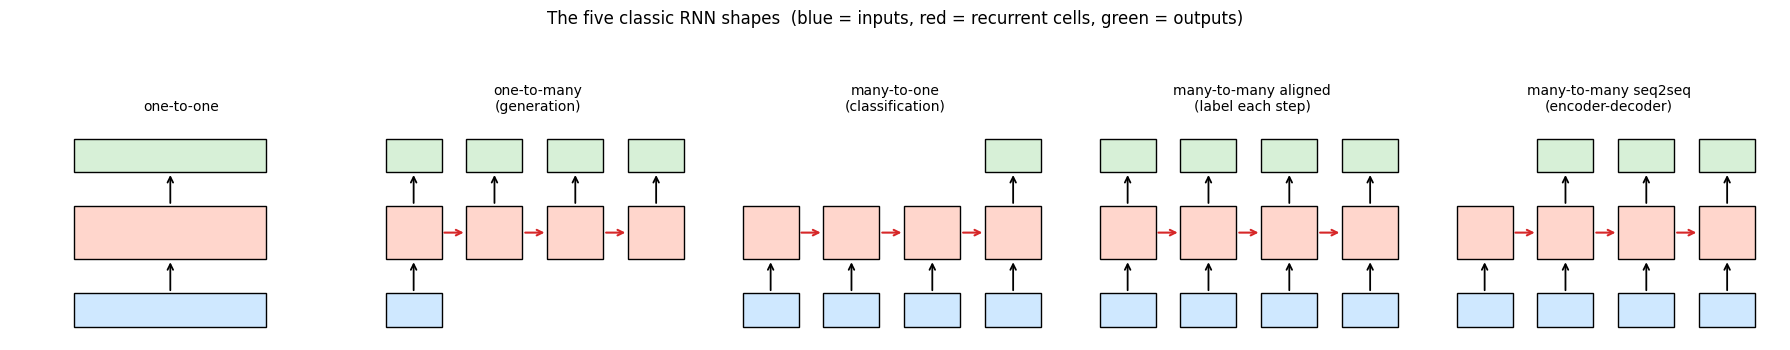

In [3]:
def draw_shape(ax, title, n_in, n_out, aligned=False):
    '''Draw a schematic of one RNN shape. Red boxes = recurrent cells,
       blue below = inputs, green above = outputs.'''
    steps = max(n_in, n_out)
    for t in range(steps):
        x = t * 1.3
        ax.add_patch(plt.Rectangle((x, 1), 0.9, 0.8, color="#ffd6cc", ec="black"))
        if t < steps - 1:  # recurrent arrow between cells
            ax.annotate("", xy=(x + 1.3, 1.4), xytext=(x + 0.9, 1.4),
                        arrowprops=dict(arrowstyle="->", lw=1.5, color="#d62728"))

    # inputs (blue) — placed under the first n_in cells
    in_positions = range(n_in) if not (n_in == 1) else [0]
    for t in in_positions:
        x = t * 1.3
        ax.add_patch(plt.Rectangle((x, 0), 0.9, 0.5, color="#cfe8ff", ec="black"))
        ax.annotate("", xy=(x + 0.45, 1.0), xytext=(x + 0.45, 0.5),
                    arrowprops=dict(arrowstyle="->", lw=1.3))

    # outputs (green) — for seq2seq (n_in many, n_out many but not aligned) put outputs on the right
    if aligned or n_out == steps:
        out_positions = range(n_out)
    else:
        out_positions = range(steps - n_out, steps)  # outputs at the end (seq2seq / many-to-one)
    for t in out_positions:
        x = t * 1.3
        ax.add_patch(plt.Rectangle((x, 2.3), 0.9, 0.5, color="#d7f0d7", ec="black"))
        ax.annotate("", xy=(x + 0.45, 2.3), xytext=(x + 0.45, 1.8),
                    arrowprops=dict(arrowstyle="->", lw=1.3))

    ax.set_xlim(-0.3, steps * 1.3)
    ax.set_ylim(-0.2, 3.1)
    ax.axis("off")
    ax.set_title(title, fontsize=10)

fig, axes = plt.subplots(1, 5, figsize=(18, 3.2))
draw_shape(axes[0], "one-to-one", 1, 1)
draw_shape(axes[1], "one-to-many\n(generation)", 1, 4)
draw_shape(axes[2], "many-to-one\n(classification)", 4, 1)
draw_shape(axes[3], "many-to-many aligned\n(label each step)", 4, 4, aligned=True)
draw_shape(axes[4], "many-to-many seq2seq\n(encoder-decoder)", 4, 3)
plt.suptitle("The five classic RNN shapes  (blue = inputs, red = recurrent cells, green = outputs)", y=1.08)
plt.tight_layout()
plt.show()

## 5. Build a vanilla RNN cell from scratch (pure NumPy)

Nothing makes an idea concrete like implementing it. Below we implement the recurrence equation
literally. We do **not** train anything — we just set random weights and **run the forward pass**
so we can watch the hidden state (the memory) evolve as it reads our temperature sequence.

We'll use:
- `input_size = 1` (each step is a single number)
- `hidden_size = 3` (memory is a 3-dimensional vector — small enough to print)
- `output_size = 1` (predict a single number per step)

In [ ]:
class VanillaRNNCell:
    '''A hand-written vanilla RNN cell. Forward pass only (no learning).

    It implements exactly:   h_t = tanh(W_xh @ x_t + W_hh @ h_{t-1} + b_h)
                             y_t = W_hy @ h_t + b_y
    '''
    def __init__(self, input_size, hidden_size, output_size, seed=0):
        rng = np.random.default_rng(seed)
        # Weights are initialized small & random. In a real model these are LEARNED.
        self.W_xh = rng.normal(0, 0.3, size=(hidden_size, input_size))   # input  -> hidden
        self.W_hh = rng.normal(0, 0.3, size=(hidden_size, hidden_size))  # hidden -> hidden (the memory link)
        self.W_hy = rng.normal(0, 0.3, size=(output_size, hidden_size))  # hidden -> output
        self.b_h = np.zeros((hidden_size, 1))
        self.b_y = np.zeros((output_size, 1))
        self.hidden_size = hidden_size

    def step(self, x_t, h_prev):
        '''Process ONE time step. Returns (new hidden state h_t, output y_t).'''
        x_t = np.array(x_t).reshape(-1, 1)            # make it a column vector (input_size, 1)
        # --- the recurrence equation, line by line ---
        pre_activation = self.W_xh @ x_t + self.W_hh @ h_prev + self.b_h
        h_t = np.tanh(pre_activation)                 # squash into (-1, 1): this is the new MEMORY. the size of h_t is (hidden_size, 1)
        y_t = self.W_hy @ h_t + self.b_y              # a linear read-out of the memory
        return h_t, y_t

    def forward(self, sequence):
        '''Run over a whole sequence, returning the memory and output at every step.'''
        # IMPORTANT: W_xx are learnable parameters, updated by gradient descente. So we initialize them with Xavier, Kaiming or similar methods.
        # But hidden states are NOT learnable parameters. They are the "memory" of the network. 
        # We initialize the hidden state to zeros at the start of each sequence, but it is updated as we process each time step.
        h = np.zeros((self.hidden_size, 1))           # h_0: start with EMPTY memory
        hidden_states, outputs = [], []
        for x_t in sequence:                          # <-- the loop over TIME
            h, y = self.step([x_t], h)                # feed previous memory `h` back in
            hidden_states.append(h.ravel())           # ravel() flattens the column vector into a 1D array for easier viewing
            outputs.append(y.item())                  # y is a 1x1 array -> take its scalar value
        return np.array(hidden_states), np.array(outputs)


cell = VanillaRNNCell(input_size=1, hidden_size=3, output_size=1, seed=0)
hidden_states, outputs = cell.forward(sequence)

# We are not training the network here, so the outputs are not meaningful. The point is to see how the memory (hidden state) evolves over time.
print("Input sequence :", np.round(sequence, 2).tolist())
print("\nHidden state (3-dim memory) after each step:")
for t, h in enumerate(hidden_states):
    print(f"  t={t}:  h = {np.round(h, 3)}")
print("\nRaw outputs y_t:", np.round(outputs, 3).tolist())

Input sequence : [10.0, 10.5, 11.2, 12.0, 12.4, 13.1, 14.0, 14.6]

Hidden state (3-dim memory) after each step:
  t=0:  h = [ 0.36  -0.377  0.958]
  t=1:  h = [ 0.517 -0.526  0.961]
  t=2:  h = [ 0.556 -0.533  0.968]
  t=3:  h = [ 0.579 -0.547  0.976]
  t=4:  h = [ 0.591 -0.556  0.979]
  t=5:  h = [ 0.61  -0.573  0.984]
  t=6:  h = [ 0.633 -0.596  0.989]
  t=7:  h = [ 0.649 -0.61   0.991]

Raw outputs y_t: [-0.585, -0.685, -0.715, -0.733, -0.742, -0.755, -0.772, -0.783]


### Watch the memory evolve

The 3 numbers of the hidden state form the network's *running summary*. As new readings arrive,
each hidden unit slides toward some value — that trajectory **is** the memory reacting to the
input. (These particular values are meaningless because the weights are random & untrained; the
*point* is to see that the state carries forward and changes smoothly with the inputs.)

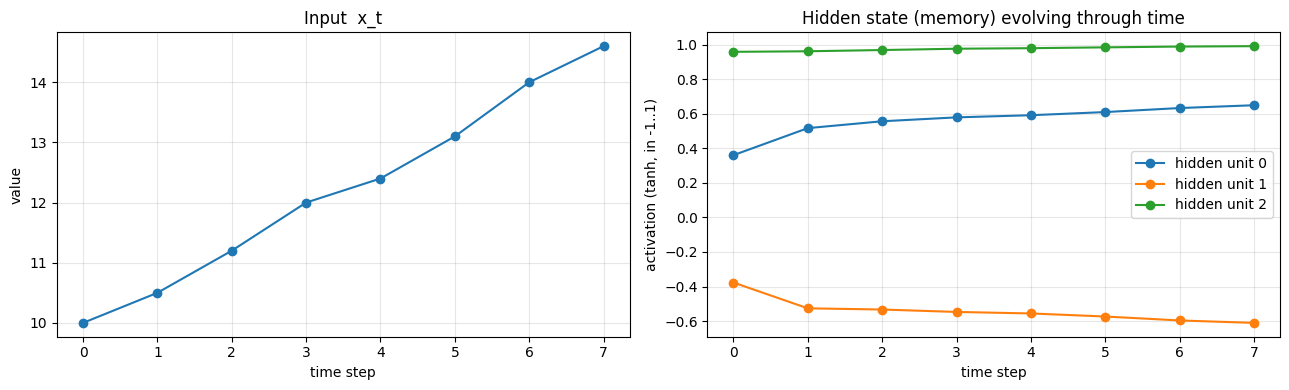

In [5]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

# left: the input sequence
ax1.plot(sequence, marker="o", color="#1f77b4")
ax1.set_title("Input  x_t")
ax1.set_xlabel("time step"); ax1.set_ylabel("value"); ax1.grid(alpha=0.3)

# right: each of the 3 hidden units over time
for i in range(hidden_states.shape[1]):
    ax2.plot(hidden_states[:, i], marker="o", label=f"hidden unit {i}")
ax2.set_title("Hidden state (memory) evolving through time")
ax2.set_xlabel("time step"); ax2.set_ylabel("activation (tanh, in -1..1)")
ax2.legend(); ax2.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Proof that memory matters: shuffle the sequence

If the RNN really uses order, then feeding the **same numbers in a different order** must produce
a **different final memory**. A memoryless model would give the same summary regardless of order.
Let's check.

In [6]:
shuffled = sequence.copy()
np.random.default_rng(42).shuffle(shuffled)

h_orig, _ = cell.forward(sequence)
h_shuf, _ = cell.forward(shuffled)

print("Original order :", np.round(sequence, 2).tolist())
print("Shuffled order :", np.round(shuffled, 2).tolist())
print()
print("Final memory (original):", np.round(h_orig[-1], 4))
print("Final memory (shuffled):", np.round(h_shuf[-1], 4))
print()
print("Different final memory for the same numbers in a different order?  ->",
      not np.allclose(h_orig[-1], h_shuf[-1]))
print("\n==> The hidden state depends on ORDER. The network genuinely has memory.")

Original order : [10.0, 10.5, 11.2, 12.0, 12.4, 13.1, 14.0, 14.6]
Shuffled order : [12.0, 12.4, 11.2, 14.6, 14.0, 10.5, 13.1, 10.0]

Final memory (original): [ 0.649  -0.6101  0.9908]
Final memory (shuffled): [ 0.533  -0.4859  0.948 ]

Different final memory for the same numbers in a different order?  -> True

==> The hidden state depends on ORDER. The network genuinely has memory.


## 6. Recap & what's next

**The mental model to keep:**

- An RNN processes a sequence **one step at a time**, maintaining a **hidden state** = *memory*.
- One equation, applied repeatedly with **shared weights**:
  $h_t = \tanh(W_{xh}x_t + W_{hh}h_{t-1} + b_h)$.
- Unrolled, information **flows forward through time** along the hidden-state arrows.
- Pick the **shape** (one-to-one / one-to-many / many-to-one / many-to-many / seq2seq) to match
  your problem.
- We built a cell in NumPy and *saw* the memory carry information and depend on order.

**What we skipped on purpose:** *learning*. Right now the weights are random. In the next
notebook we let the network **learn** the weights from data using PyTorch, and we carefully
decode the input tensor shapes `(batch, time, features)` that trip everyone up at first.

➡️ **Next:** `02_first_rnn_pytorch.ipynb` — train your first real RNN to predict a signal, using
both a manual per-step loop (`nn.RNNCell`) and the batched `nn.RNN`.